<a href="https://colab.research.google.com/github/aarthyviven/DataScienceNotebook/blob/main/Handling_Skewness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Skewness Correction Transformations - Numerical Values**

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PowerTransformer

# 1. Create a sample skewed dataset
data = np.array([1, 5, 10, 50, 100, 500, 1000, 5000]).reshape(-1, 1)
df = pd.DataFrame(data, columns=['Original'])

# 2. Manual Transformations (Log and Square Root)
df['Log'] = np.log(df['Original'])
df['Square_Root'] = np.sqrt(df['Original'])

# 3. Box-Cox (Requires positive data)
pt_box_cox = PowerTransformer(method='box-cox')
df['Box_Cox'] = pt_box_cox.fit_transform(df[['Original']])

# 4. Yeo-Johnson (Handles zero/negative data)
pt_yeo = PowerTransformer(method='yeo-johnson')
df['Yeo_Johnson'] = pt_yeo.fit_transform(df[['Original']])

print(df)

   Original       Log  Square_Root   Box_Cox  Yeo_Johnson
0         1  0.000000     1.000000 -1.578889    -1.512380
1         5  1.609438     2.236068 -0.982185    -1.029363
2        10  2.302585     3.162278 -0.725198    -0.770372
3        50  3.912023     7.071068 -0.128493    -0.137944
4       100  4.605170    10.000000  0.128493     0.133490
5       500  6.214608    22.360680  0.725198     0.745870
6      1000  6.907755    31.622777  0.982185     1.000547
7      5000  8.517193    70.710678  1.578889     1.570152


# **Skewness Correctness Transformations - Visualizations**

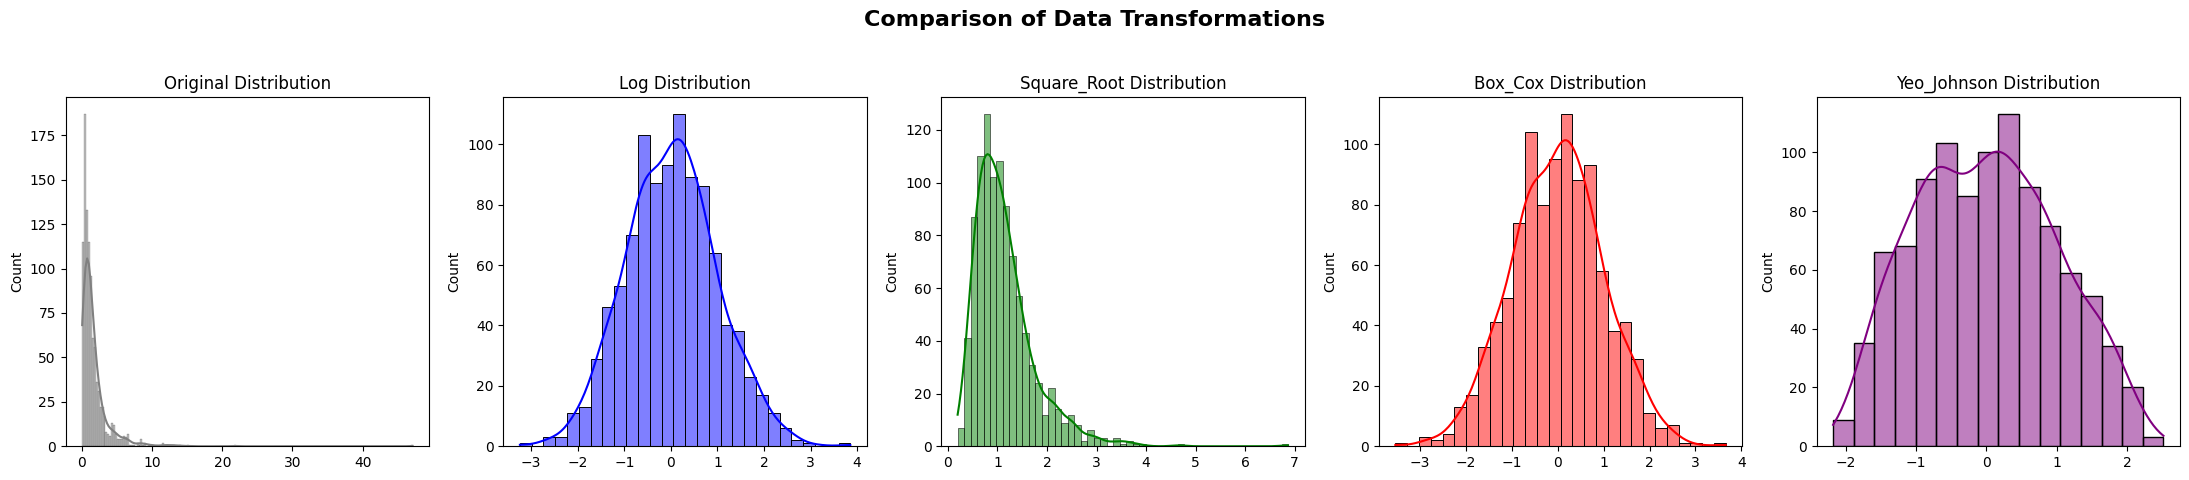

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer

# 1. Generate right-skewed data (Lognormal distribution)
np.random.seed(42)
data = np.random.lognormal(mean=0, sigma=1, size=1000).reshape(-1, 1)
df = pd.DataFrame(data, columns=['Original'])

# 2. Apply Transformations
df['Log'] = np.log(df['Original'])
df['Square_Root'] = np.sqrt(df['Original'])

pt_box_cox = PowerTransformer(method='box-cox')
df['Box_Cox'] = pt_box_cox.fit_transform(df[['Original']])

pt_yeo = PowerTransformer(method='yeo-johnson')
df['Yeo_Johnson'] = pt_yeo.fit_transform(df[['Original']])

# 3. Plotting
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=False)
fig.suptitle('Comparison of Data Transformations', fontsize=16, fontweight='bold')

columns = ['Original', 'Log', 'Square_Root', 'Box_Cox', 'Yeo_Johnson']
colors = ['gray', 'blue', 'green', 'red', 'purple']

for i, col in enumerate(columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color=colors[i])
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# **1. Log Transformation**


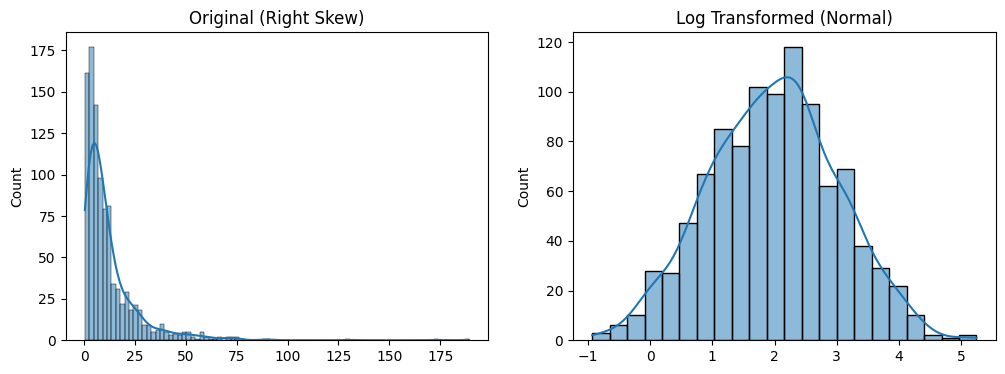

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Generate extreme right-skewed data
data = np.random.lognormal(mean=2, sigma=1, size=1000)
transformed = np.log(data)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data, kde=True, ax=ax1).set_title("Original (Right Skew)")
sns.histplot(transformed, kde=True, ax=ax2).set_title("Log Transformed (Normal)")
plt.show()


## **2. Square Root Transformation**

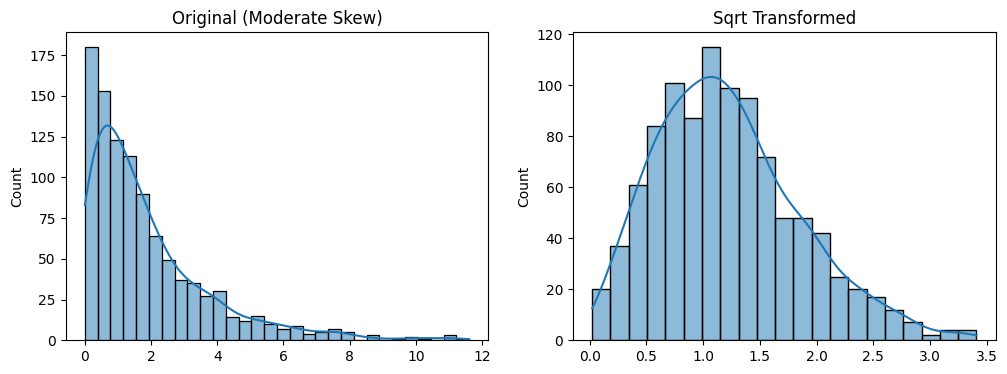

In [14]:
# Generate moderately skewed data
data = np.random.exponential(scale=2, size=1000)
transformed = np.sqrt(data)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data, kde=True, ax=ax1).set_title("Original (Moderate Skew)")
sns.histplot(transformed, kde=True, ax=ax2).set_title("Sqrt Transformed")
plt.show()


## **3. Box-Cox Transformation**

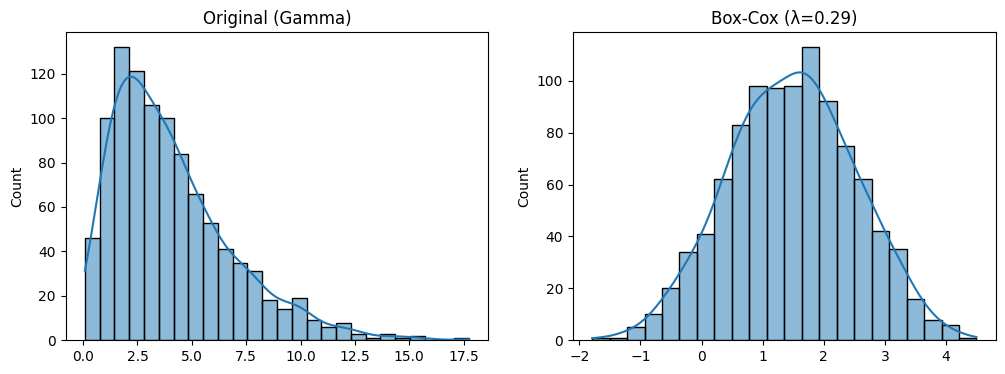

In [25]:
from scipy import stats

# Generate positive skewed data
data = np.random.gamma(shape=2, scale=2, size=1000)
transformed, best_lambda = stats.boxcox(data)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data, kde=True, ax=ax1).set_title("Original (Gamma)")
sns.histplot(transformed, kde=True, ax=ax2).set_title(f"Box-Cox (λ={best_lambda:.2f})")
plt.show()


# **4. Yeo-Johnson Transformation**


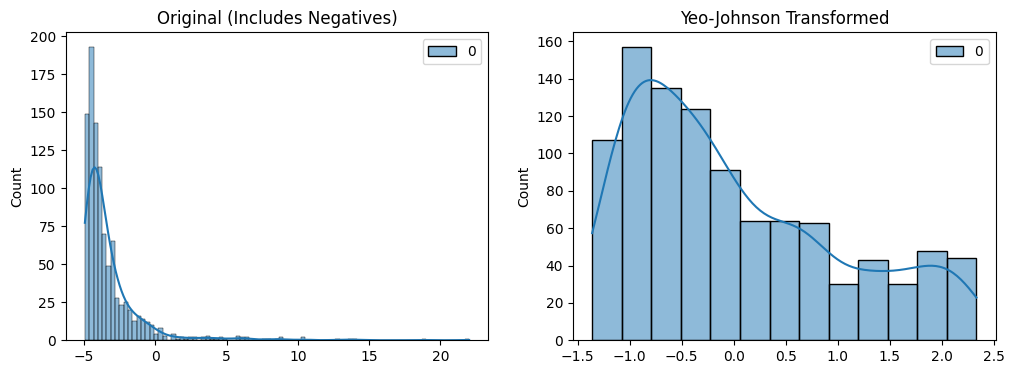

In [27]:
from sklearn.preprocessing import PowerTransformer

# Generate skewed data with negative values
data = (np.random.lognormal(0, 1, 1000) - 5).reshape(-1, 1)
pt = PowerTransformer(method='yeo-johnson')
transformed = pt.fit_transform(data)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data, kde=True, ax=ax1).set_title("Original (Includes Negatives)")
sns.histplot(transformed, kde=True, ax=ax2).set_title("Yeo-Johnson Transformed")
plt.show()
